<a href="https://colab.research.google.com/github/noo-nine/shallow-vs-deep-nns/blob/main/shallow_250hns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()

Saving map_data.csv to map_data.csv


In [5]:
data = pd.read_csv('map_data.csv')

In [6]:
X = data[['x', 'y']].values

Y = data['label'].values

In [7]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim

In [8]:
class ShallowNet(nn.Module):
    def __init__(self, input_size = 2, hidden_size = 2, output_size = 2):
        super(ShallowNet, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.hidden(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model = ShallowNet(input_size = 2, hidden_size = 250, output_size = 2)

loss_fn= nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.1)

for epochs in range(1, 201):

    inputs = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(Y, dtype=torch.long)
    outputs = model(inputs)


    loss = loss_fn(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epochs) % 10 == 0:
        print(f"Epoch {epochs}:- Loss: {loss.item():.4f}")

Epoch 10:- Loss: 0.3553
Epoch 20:- Loss: 0.3248
Epoch 30:- Loss: 0.3065
Epoch 40:- Loss: 0.2954
Epoch 50:- Loss: 0.2862
Epoch 60:- Loss: 0.2803
Epoch 70:- Loss: 0.2761
Epoch 80:- Loss: 0.2732
Epoch 90:- Loss: 0.2712
Epoch 100:- Loss: 0.2680
Epoch 110:- Loss: 0.2565
Epoch 120:- Loss: 0.2437
Epoch 130:- Loss: 0.2360
Epoch 140:- Loss: 0.2317
Epoch 150:- Loss: 0.2285
Epoch 160:- Loss: 0.2287
Epoch 170:- Loss: 0.2243
Epoch 180:- Loss: 0.2227
Epoch 190:- Loss: 0.2216
Epoch 200:- Loss: 0.2201


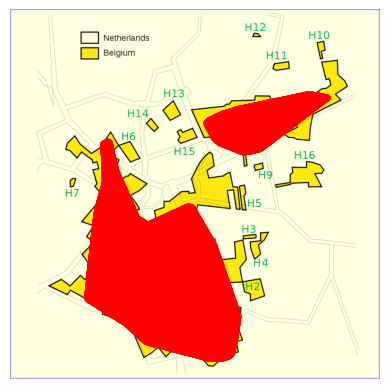

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('Baarle-Nassau_Baarle-Hertog.png')
plt.imshow(img)
plt.axis('off')

inputs = torch.tensor(X, dtype = torch.float32)

with torch.no_grad():
    outputs = model(inputs)
    preds = torch.argmax(outputs, dim = 1).numpy()

plt.scatter(X[preds == 1, 0], X[preds == 1, 1], c = 'red', s = 4, label = 'Netherlands', alpha = 0.5)
plt.scatter(X[preds == 0, 0], X[preds == 0, 1], c = 'none', s = 4, label = 'Belgium', alpha = 0.5)